In [1]:
import numpy as np, curvedsky as cs, plottools as pl, cmb as CMB, cosmology, healpy as hp, local, tools_cmb
from matplotlib.pyplot import *
import warnings
warnings.filterwarnings("ignore")
ac2rad  = np.pi/10800.
deg2rad = np.pi/180.
Tcmb  = CMB.Tcmb    # CMB temperature

In [2]:
lmax = 2048
l = np.linspace(0,lmax,lmax+1)

In [3]:
aobj0 = local.init_analysis(freq='143',dtype='hm1',ascale=0.5)
aobj1 = local.init_analysis(freq='143',dtype='hm2',ascale=0.5)

In [32]:
wind0 = local.set_mask(aobj0.famask)[0]
wind1 = local.set_mask(aobj1.famask)[0]

In [68]:
mask = hp.fitsfunc.read_map('../data/plk_biref/mask/COM_Mask_Lensing_2048_R3.00_a1.0deg.fits')

In [117]:
W = wind0 * wind1

In [118]:
tmap0 = W*tools_cmb.reduc_map(aobj0.dtype,aobj0.fimap['s'][0],field=0)
tmap1 = W*tools_cmb.reduc_map(aobj1.dtype,aobj1.fimap['s'][0],field=0)

In [119]:
Tmap0 = W*tools_cmb.reduc_map(aobj0.dtype,aobj0.fimap['s'][1],field=0)
Tmap1 = W*tools_cmb.reduc_map(aobj1.dtype,aobj1.fimap['s'][1],field=0)

In [120]:
Nmap0 = W*tools_cmb.reduc_map(aobj0.dtype,aobj0.fimap['n'][1],field=0)
Nmap1 = W*tools_cmb.reduc_map(aobj1.dtype,aobj1.fimap['n'][1],field=0)

In [121]:
talm0 = cs.utils.hp_map2alm(2048,lmax,lmax,tmap0)
talm1 = cs.utils.hp_map2alm(2048,lmax,lmax,tmap1)

In [122]:
Talm0 = cs.utils.hp_map2alm(2048,lmax,lmax,Tmap0+Nmap0)
Talm1 = cs.utils.hp_map2alm(2048,lmax,lmax,Tmap1+Nmap1)

In [123]:
dcl = cs.utils.alm2cl(lmax,talm0-talm1)
cl0 = cs.utils.alm2cl(lmax,talm0)
cl1 = cs.utils.alm2cl(lmax,talm1)
xl  = cs.utils.alm2cl(lmax,talm0,talm1)

In [124]:
dCl = cs.utils.alm2cl(lmax,Talm0-Talm1)
Cl0 = cs.utils.alm2cl(lmax,Talm0)
Cl1 = cs.utils.alm2cl(lmax,Talm1)
Xl  = cs.utils.alm2cl(lmax,Talm0,Talm1)

In [125]:
ibl = tools_cmb.get_transfer('143',lmax)

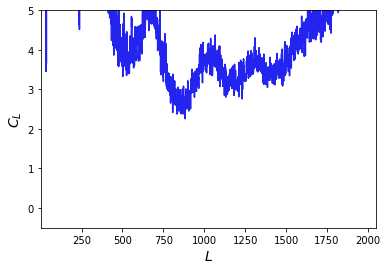

In [127]:
pl.plot_1dstyle(xmin=2,xmax=2048,ymin=-.5,ymax=5.)
#plot(l,dcl/dCl)
#lot(l,cl0/Cl0)
#lot(l,cl1/Cl1)
plot(l,(xl-Xl)/Xl)
#axhline(1,color='k')

In [25]:
qmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=1)
umap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][0],field=2)

In [26]:
sQmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=1)
sUmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['s'][1],field=2)
nQmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=1)
nUmap = tools_cmb.reduc_map(aobj.dtype,aobj.fimap['n'][1],field=2)

In [27]:
ealm, balm = cs.utils.hp_map2alm_spin(2048,lmax,lmax,2,qmap,umap)

In [28]:
Ealm, Balm = cs.utils.hp_map2alm_spin(2048,lmax,lmax,2,(sQmap+nQmap),(sUmap+nUmap))

In [29]:
ee = cs.utils.alm2cl(lmax,ealm)
bb = cs.utils.alm2cl(lmax,balm)
EE = cs.utils.alm2cl(lmax,Ealm)
BB = cs.utils.alm2cl(lmax,Balm)

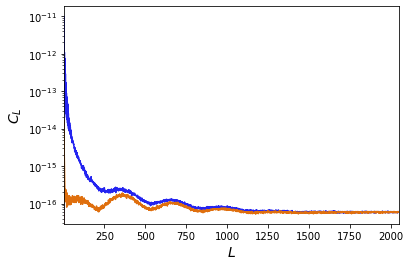

In [36]:
pl.plot_1dstyle(xmin=2,xmax=2048,ylog=True)
plot(ee)
plot(EE)

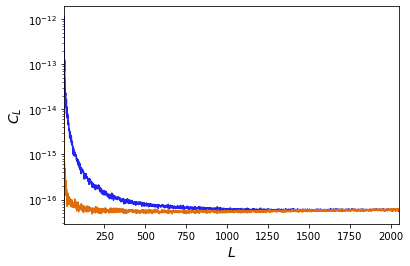

In [33]:
pl.plot_1dstyle(xmin=2,xmax=2048,ylog=True)
plot(bb)
plot(BB)